In [1841]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

import datetime, nltk, warnings
import matplotlib.cm as cm
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

import warnings

warnings.filterwarnings('ignore')

1. groupby :- df.groupby([<column1>, <column2>, ...])[<target_column>].<aggregation>()

<column1>, <column2> → grouping ke basis

<target_column> → jis column par calculation karni hai

<aggregation>() → jaise .sum(), .count(), .mean()

2. lambda 

In [1842]:
df = pd.read_csv(r"data.csv", encoding="ISO-8859-1")

print(df.head())

  InvoiceNo StockCode                          Description  Quantity     InvoiceDate  UnitPrice  CustomerID         Country
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6  12/1/2010 8:26       2.55     17850.0  United Kingdom
1    536365     71053                  WHITE METAL LANTERN         6  12/1/2010 8:26       3.39     17850.0  United Kingdom
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8  12/1/2010 8:26       2.75     17850.0  United Kingdom
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6  12/1/2010 8:26       3.39     17850.0  United Kingdom
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6  12/1/2010 8:26       3.39     17850.0  United Kingdom


Data cleaning

In [1843]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'], dtype='object')


fix the breakable column

In [1844]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(df.head())

  InvoiceNo StockCode                          Description  Quantity     InvoiceDate  UnitPrice  CustomerID         Country
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6  12/1/2010 8:26       2.55     17850.0  United Kingdom
1    536365     71053                  WHITE METAL LANTERN         6  12/1/2010 8:26       3.39     17850.0  United Kingdom
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8  12/1/2010 8:26       2.75     17850.0  United Kingdom
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6  12/1/2010 8:26       3.39     17850.0  United Kingdom
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6  12/1/2010 8:26       3.39     17850.0  United Kingdom


In [1845]:
df.shape

(541909, 8)

In [1846]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [1847]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [1848]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Duplicate

In [1849]:
# for checking dublicates
df.duplicated().sum()

np.int64(5268)

In [1850]:
# removing dublicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

# Missing data

In [1851]:
# missing data in description and customer id 
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [1852]:
# missing data percentage calcutae 
df.isnull().sum()/df.shape[0]*100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.270945
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     25.163377
Country         0.000000
dtype: float64

In [1853]:
#  droping missing customer id 
df = df.dropna(subset=["CustomerID"])
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [1854]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

EDA

In [1855]:
print("Rows and Columns:", df.shape)

Rows and Columns: (401604, 8)


In [1856]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'], dtype='object')

Countries from where orders are made 

In [1857]:
# creating total price 
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Top country by order

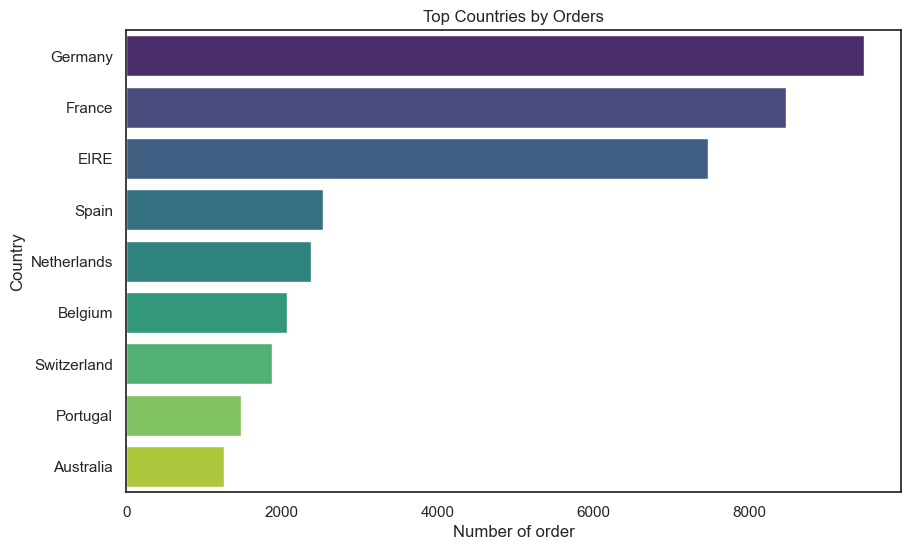

In [1858]:
top_countries = df["Country"].value_counts().head(10)[1:11]

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')

plt.title("Top Countries by Orders")
plt.xlabel("Number of order")
plt.ylabel("Country")
plt.show()

# no. of unique customers,  stock country

In [1859]:
num_customers= df["CustomerID"].nunique()
print(num_customers)

4372


In [1860]:
num_products= df["StockCode"].nunique()
print(num_products)

3684


In [1861]:
num_countries= df["Country"].nunique()
print(num_countries)

37


In [1862]:
num_invoices = df["InvoiceNo"].nunique()

In [1863]:
summary_df = pd.DataFrame([{
    "Customers": num_customers,
    "Products": num_products,
    "Countries": num_countries,
    "Invoices": num_invoices
}])
summary_df    

,Customers,Products,Countries,Invoices
0,4372,3684,37,22190


In [1864]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'], dtype='object')


# Top selling product 

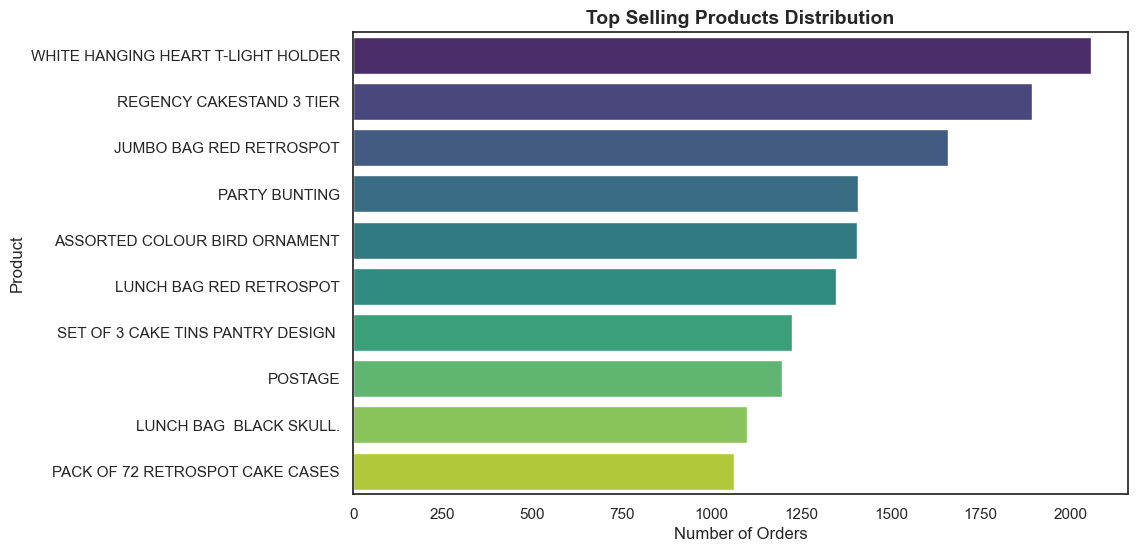

In [1865]:
top_products = df["Description"].value_counts().head(10) 
plt.figure(figsize=(10,6)) 

sns.barplot(x=top_products.values, y=top_products.index, palette='viridis') 
plt.title("Top Selling Products Distribution", fontsize=14, fontweight='bold') 
plt.xlabel("Number of Orders") 
plt.ylabel("Product") 

plt.show()

# Customer who spends more money ( for all )

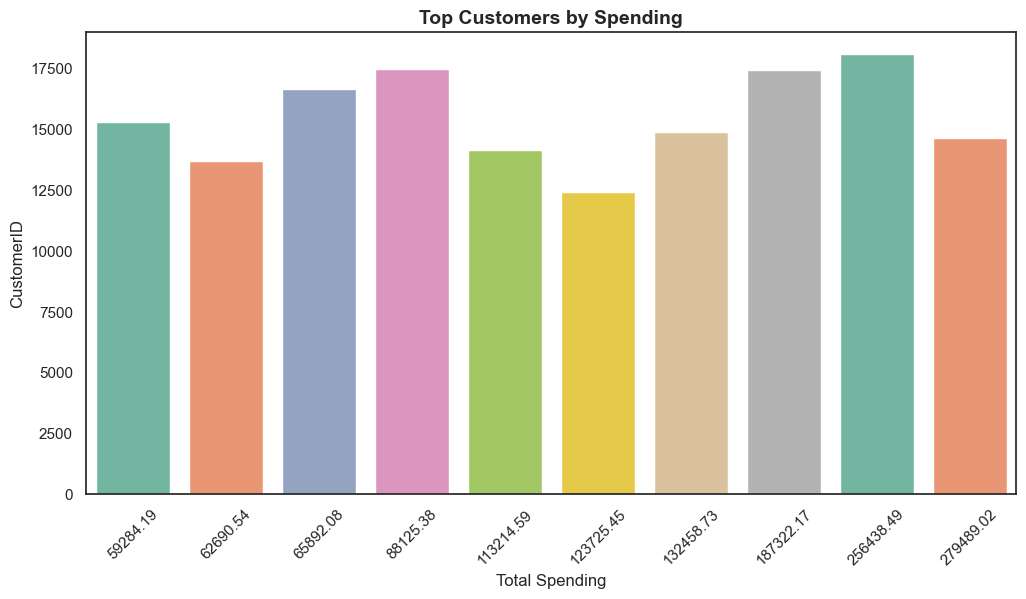

In [1866]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
top_customers = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))

sns.barplot(x=top_customers.values, y=top_customers.index,  palette='Set2')

plt.title("Top Customers by Spending", fontsize=14, fontweight='bold')
plt.xlabel("Total Spending")
plt.ylabel("CustomerID")
plt.xticks(rotation=45)
plt.show()

# For top 10 customers only

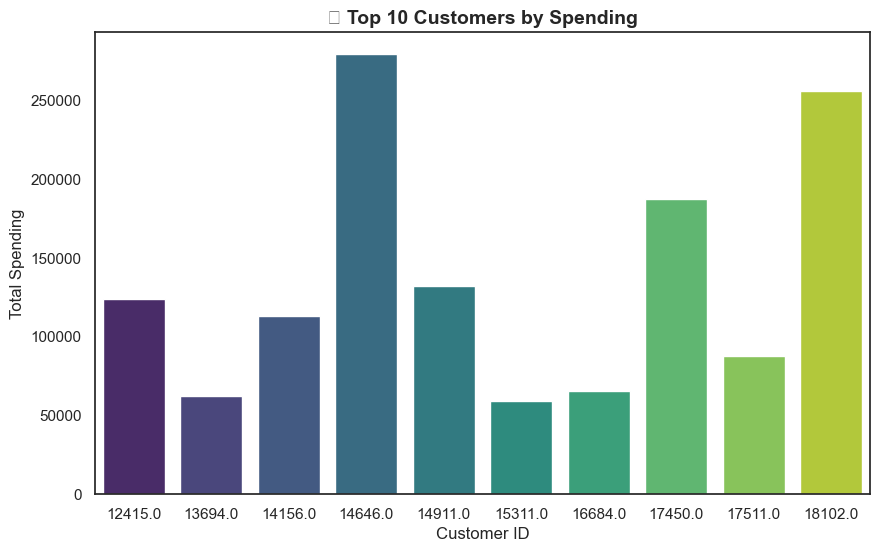

In [1867]:
top_customers = (
    df.groupby("CustomerID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_customers,
    y="TotalPrice",
    x="CustomerID",
    palette="viridis"
)

plt.title("💰 Top 10 Customers by Spending", fontsize=14, fontweight='bold')
plt.ylabel("Total Spending")
plt.xlabel("Customer ID")

plt.show()

# Number of products purchased in every transaction:

In [1868]:
temp = df.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate'].count()

nb_products_per_basket = temp.rename(columns = {'InvoiceDate':'Number of products'})
nb_products_per_basket[:10].sort_values('CustomerID')

,CustomerID,InvoiceNo,Number of products
0,12346.0,541431,1
1,12346.0,C541433,1
2,12347.0,537626,31
3,12347.0,542237,29
4,12347.0,549222,24
5,12347.0,556201,18
6,12347.0,562032,22
7,12347.0,573511,47
8,12347.0,581180,11
9,12348.0,539318,17


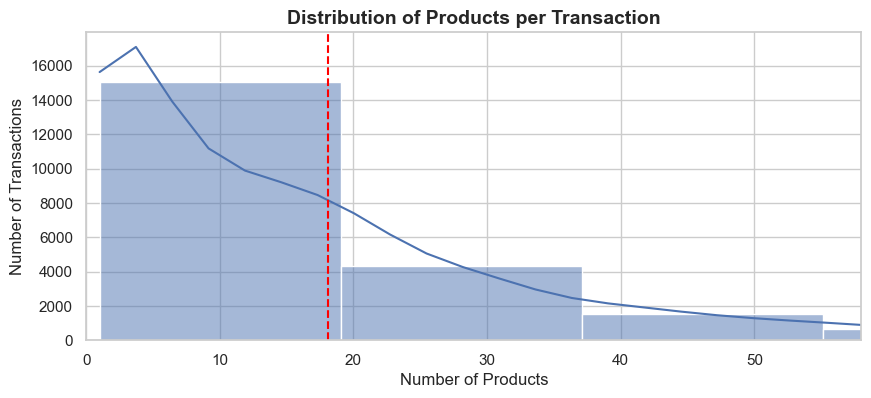

In [1869]:
sns.set_style("whitegrid")

max_products = np.percentile(nb_products_per_basket['Number of products'], 95) 

mean_val = nb_products_per_basket['Number of products'].mean()

plt.figure(figsize=(10,4))

sns.histplot(
    nb_products_per_basket['Number of products'],
    bins=30,
    palette='Set2',
    kde=True
)


plt.axvline(mean_val, color='red', linestyle='--', label=f'Avg: {mean_val:.2f}')

plt.title("Distribution of Products per Transaction", fontsize=14, fontweight='bold')
plt.xlabel("Number of Products", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.xlim(0, max_products)
plt.show()

# Order cancel 

In [1870]:
nb_products_per_basket['order_canceled'] = nb_products_per_basket['InvoiceNo'].apply(lambda x: int ('C' in x))

n1 = nb_products_per_basket['order_canceled'].sum()
n2 = nb_products_per_basket.shape[0]

print('Percentage of Order Cancel: ', round(n1/n2*100,2), "%")

Percentage of Order Cancel:  16.47 %


In [1871]:
nb_products_per_basket.head()

,CustomerID,InvoiceNo,Number of products,order_canceled
0,12346.0,541431,1,0
1,12346.0,C541433,1,1
2,12347.0,537626,31,0
3,12347.0,542237,29,0
4,12347.0,549222,24,0


# Top 10 Customers with Most Cancellations

In [1872]:


top_cancel_customers = (
    nb_products_per_basket
    .groupby('CustomerID')['order_canceled']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_cancel_customers


,CustomerID,order_canceled
0,14911.0,47
1,17841.0,45
2,14606.0,35
3,14527.0,31
4,15311.0,27
5,16422.0,24
6,13089.0,21
7,13408.0,19
8,12471.0,19
9,13534.0,18


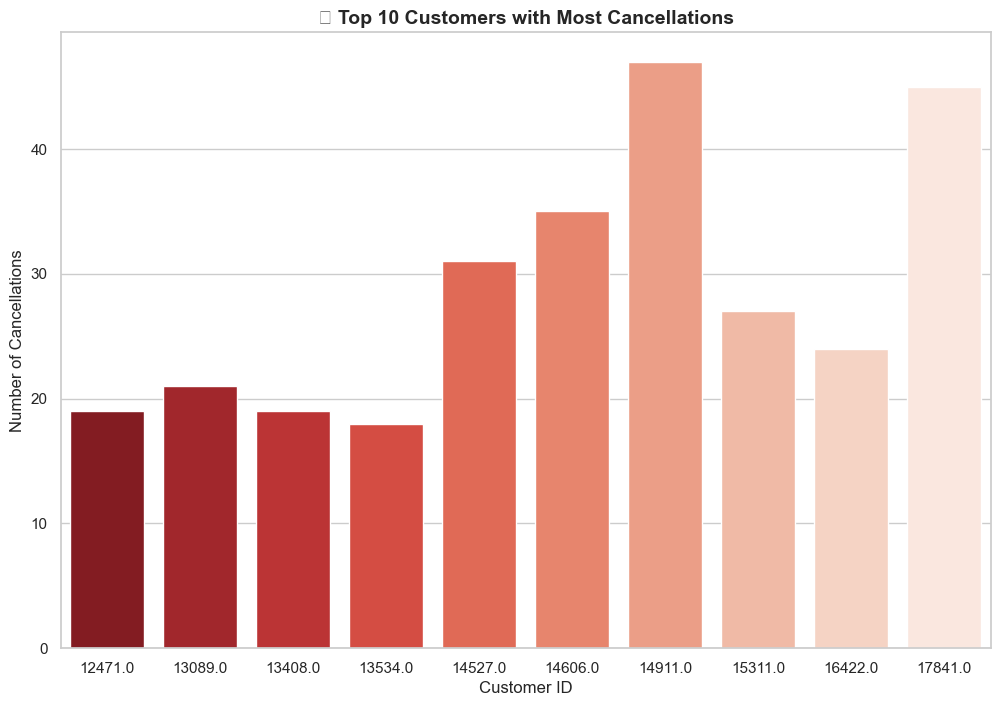

In [1873]:
plt.figure(figsize=(12,8))
# sns.set_style("whitegrid")

sns.barplot(
    data=top_cancel_customers,
    y='order_canceled',
    x='CustomerID',
    palette='Reds_r'
)

plt.title("🚨 Top 10 Customers with Most Cancellations", fontsize=14, fontweight='bold')
plt.ylabel("Number of Cancellations", fontsize=12)
plt.xlabel("Customer ID", fontsize=12)


plt.show()

# Negative quantity (return/ cancel ) check

In [1874]:
df_check = df[df['Quantity'] < 0 ] [
    ['CustomerID','Quantity','StockCode','Description','UnitPrice']
]

#checking negative transaction
for index, col in df_check.iterrows():

    #checking  kya dataset me same product ka positive purchase exist karta hai
    if df[
        (df['CustomerID'] == col[0]) &
        (df['Quantity'] == -col[1]) &
        (df['Description'] == col[2])
    ].shape[0] == 0:

        # if not found matching purchase then print 
        print(df_check.loc[index])
        print("--------->Hypothesis not found")

        break

CustomerID      14527.0
Quantity             -1
StockCode             D
Description    Discount
UnitPrice          27.5
Name: 141, dtype: object
--------->Hypothesis not found


# Checking negative rows again but this time ignore Discount 

In [1875]:
df_check = df[
    (df['Quantity'] < 0) &
    (df['Description'] != 'Discount')
    ][
    ['CustomerID','Quantity','StockCode','Description','UnitPrice']
]

for index, col in df_check.iterrows():

     if df[
        (df['CustomerID'] == col[0]) &
        (df['Quantity'] == -col[1]) &
        (df['Description'] == col[2])
    ].shape[0] == 0:

        print(index, df_check.loc[index])
        print("--------->Hypothesis not found")

        break


154 CustomerID                             15311.0
Quantity                                    -1
StockCode                               35004C
Description    SET OF 3 COLOURED  FLYING DUCKS
UnitPrice                                 4.65
Name: 154, dtype: object
--------->Hypothesis not found


In [1876]:
# dataframe copy
df_cleaned = df.copy()
df_cleaned['QuantityCanceled'] = 0

# returns
returns = df[(df['Quantity'] < 0) & (df['Description'] != 'Discount')]

# purchases
purchases = df[df['Quantity'] > 0]

# merge
merged = returns.merge(
    purchases,
    on=['CustomerID','StockCode'],
    suffixes=('_return','_purchase')
)

# purchase should be before return
merged = merged[merged['InvoiceDate_purchase'] < merged['InvoiceDate_return']]

# latest purchase choose
merged = merged.sort_values('InvoiceDate_purchase').drop_duplicates(
    subset=['InvoiceNo_return','StockCode'],
    keep='last'
)

# valid returns
entry_to_remove = len(merged)

# suspicious returns
doubtfull_entry = len(returns) - entry_to_remove

print("entry_to_remove:", entry_to_remove)
print("doubtfull_entry:", doubtfull_entry)

entry_to_remove: 7533
doubtfull_entry: 1262


In [1877]:
# remove cancelled rows
df_cleaned.drop(entry_to_remove, inplace=True, errors='ignore')

# remove suspicious rows
df_cleaned.drop(doubtfull_entry, inplace=True, errors='ignore')


In [1878]:
print("Rows removed:", (entry_to_remove) + (doubtfull_entry))
print("Remaining rows:", df_cleaned.shape[0])

df_cleaned.drop(entry_to_remove, axis = 0, inplace = True,  errors='ignore')
df_cleaned.drop(doubtfull_entry, axis = 0, inplace = True,  errors='ignore')

remaining_entries = df_cleaned[(df_cleaned['Quantity'] < 0) & (df_cleaned['StockCode'] != 'D')]
print("nb of entries to delete: {}".format(remaining_entries.shape[0]))
remaining_entries.head()


Rows removed: 8795
Remaining rows: 401602
nb of entries to delete: 8795


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,QuantityCanceled
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65,0
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,0
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,0
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,0
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,0


In [1879]:
df_cleaned[(df_cleaned['CustomerID'] == 14048) & (df_cleaned['StockCode'] == '22464')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,QuantityCanceled
84247,543371,22464,HANGING METAL HEART LANTERN,3,2011-02-07 14:53:00,1.65,14048.0,United Kingdom,4.95,0
84259,543371,22464,HANGING METAL HEART LANTERN,1,2011-02-07 14:53:00,1.65,14048.0,United Kingdom,1.65,0
111968,C545852,22464,HANGING METAL HEART LANTERN,-5,2011-03-07 13:49:00,1.65,14048.0,United Kingdom,-8.25,0


In [1880]:
# stock code

list_special_codes = df_cleaned[df_cleaned['StockCode'].str.contains('^[a-zA-Z]+', regex=True)]['StockCode'].unique()
list_special_codes

array(['POST', 'D', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK'],
      dtype=object)

In [1881]:
for code in list_special_codes:
    print("{:<15} -> {:<30}".format(code, df_cleaned[df_cleaned['StockCode'] == code]['Description'].unique()[0]))

POST            -> POSTAGE                       
D               -> Discount                      
C2              -> CARRIAGE                      
M               -> Manual                        
BANK CHARGES    -> Bank Charges                  
PADS            -> PADS TO MATCH ALL CUSHIONS    
DOT             -> DOTCOM POSTAGE                
CRUK            -> CRUK Commission               


In [1882]:
df_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,QuantityCanceled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,0


In [1883]:
# word frequency graph, 
from collections import Counter

# description ko lowercase aur string me convert
text = " ".join(df_cleaned['Description'].dropna().astype(str).str.lower())

# words split
words = text.split()

stop_words = [
    'of','set','pack','and','the','in','to','for','on','with','a','an'
]

# filter words
filtered_words = [w for w in words if w.isalpha() and w not in stop_words]

# count
word_count = Counter(filtered_words)

common_words = word_count.most_common(20)

words = [w for w, c in common_words]
counts = [c for w, c in common_words]

words = word_count.most_common(30)


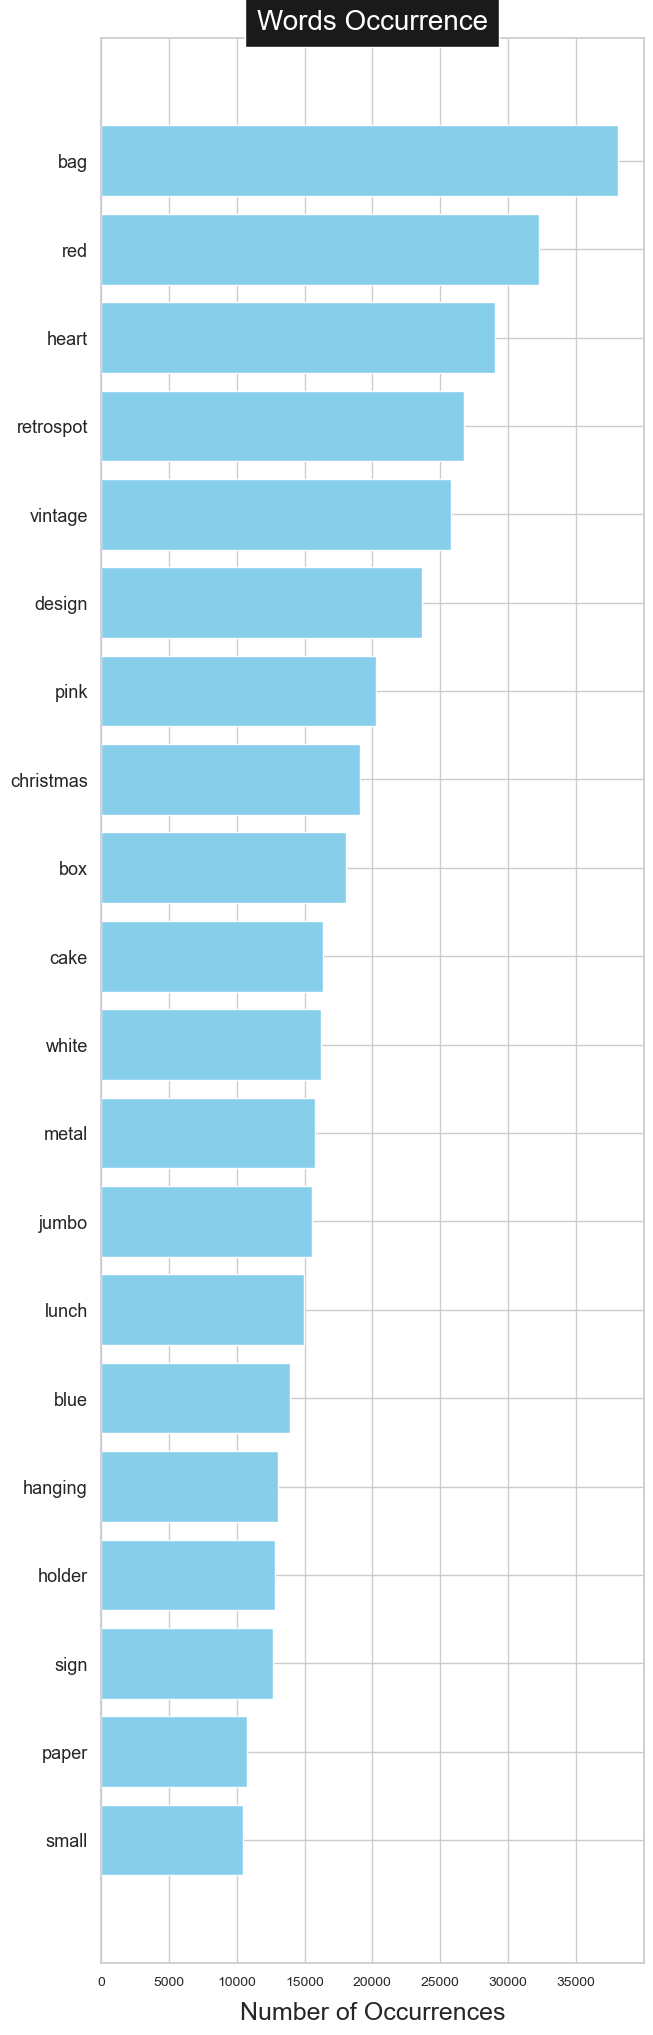

In [1884]:

# assume common_words = [('apple', 50), ('orange', 40), ...]
stop_words = ['of','set','pack','and','the','in','to','for','on','with','a','an']

# clean words
clean_words = [w for w, c in common_words if w.isalpha() and w not in stop_words]
clean_counts = [c for w, c in common_words if w.isalpha() and w not in stop_words]

# make sure lengths match
assert len(clean_words) == len(clean_counts), "Length mismatch!"

plt.rc('font', weight='normal')
fig, ax = plt.subplots(figsize=(7, 25))

y_axis = clean_counts           # values
x_axis = list(range(len(clean_words)))  # positions
x_label = clean_words           # labels

plt.barh(x_axis, y_axis, align='center', color='skyblue')
plt.yticks(x_axis, x_label, fontsize=13)
plt.xticks(fontsize=10)
plt.xlabel("Number of Occurrences", fontsize=18, labelpad=10)

ax.invert_yaxis()  # top word on top

plt.title("Words Occurrence", bbox={'facecolor':'k', 'pad':5}, 
          color='w', fontsize=20)
plt.show()


Now lets play with keywords which appreared the most 

In [1885]:

print(df_cleaned.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'QuantityCanceled'], dtype='object')


In [1886]:
final_data = df_cleaned [['InvoiceNo', 'StockCode', 'Description', 'Quantity',
                            'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'QuantityCanceled']]

In [1887]:
final_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,QuantityCanceled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,0
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,0
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,0
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,0
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,0


In [1888]:
# RFM
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


In [1889]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()


In [1890]:
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
print(rfm.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary'], dtype='object')


In [1891]:
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1,2,3,4])


In [1892]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Score'] = rfm['RFM_Score'].astype(int)

In [1893]:
rfm_final = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 
                 'R_score', 'F_score', 'M_score', 'RFM_Score']]

rfm_final.head(10)

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346.0,326,2,0.00,1,2,1,121
1,12347.0,2,7,4310.00,4,4,4,444
2,12348.0,75,4,1797.24,2,3,4,234
3,12349.0,19,1,1757.55,3,1,4,314
4,12350.0,310,1,334.40,1,1,2,112
5,12352.0,36,11,1545.41,3,4,3,343
6,12353.0,204,1,89.00,1,1,1,111
7,12354.0,232,1,1079.40,1,1,3,113
8,12355.0,214,1,459.40,1,1,2,112
9,12356.0,23,3,2811.43,3,2,4,324


In [1894]:
# segment 
def segment(row):

    rfm_score = row['RFM_Score']
    
    if rfm_score >= 444:
        return 'Platinum Customer 💎'
    elif rfm_score >=433 and rfm_score < 444:
        return 'Very Loyal Customers 💙'
    elif rfm_score >=421 and rfm_score < 433:
        return 'Becoming Loyal 💫'
    elif rfm_score >=344 and rfm_score < 421:
        return 'Recent Customer 🆕'
    elif rfm_score >=323 and rfm_score < 344:
        return 'Potential Customer 🌱'
    elif rfm_score >=311 and rfm_score < 323:
        return 'Late Bloomer 🌼'
    elif rfm_score >=224 and rfm_score < 311:
        return 'Loosing Customer ⚠️'
    elif rfm_score >=212 and rfm_score < 224:
        return 'High Risk Customer 🚨'
    elif rfm_score >=124 and rfm_score < 212:
        return 'Almost Lost Customer 😢'
    elif rfm_score >=112 and rfm_score < 124:
        return 'Evasive Customer 🕵️'
    else :
        return 'Lost Customer ❌'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [1895]:
print(rfm[['CustomerID','RFM_Score','Segment']].head(20))

    CustomerID  RFM_Score                 Segment
0      12346.0        121     Evasive Customer 🕵️
1      12347.0        444     Platinum Customer 💎
2      12348.0        234     Loosing Customer ⚠️
3      12349.0        314          Late Bloomer 🌼
4      12350.0        112     Evasive Customer 🕵️
5      12352.0        343    Potential Customer 🌱
6      12353.0        111         Lost Customer ❌
7      12354.0        113     Evasive Customer 🕵️
8      12355.0        112     Evasive Customer 🕵️
9      12356.0        324    Potential Customer 🌱
10     12357.0        314          Late Bloomer 🌼
11     12358.0        423        Becoming Loyal 💫
12     12359.0        444     Platinum Customer 💎
13     12360.0        224     Loosing Customer ⚠️
14     12361.0        111         Lost Customer ❌
15     12362.0        444     Platinum Customer 💎
16     12363.0        222    High Risk Customer 🚨
17     12364.0        433  Very Loyal Customers 💙
18     12365.0        122     Evasive Customer 🕵️


In [1896]:
print(rfm['Segment'].value_counts())


Segment
Evasive Customer 🕵️       566
Potential Customer 🌱      498
Loosing Customer ⚠️       483
Platinum Customer 💎       481
High Risk Customer 🚨      465
Late Bloomer 🌼            372
Almost Lost Customer 😢    351
Lost Customer ❌           321
Very Loyal Customers 💙    316
Recent Customer 🆕         292
Becoming Loyal 💫          227
Name: count, dtype: int64


In [1897]:
cust_per_segment = rfm.groupby('Segment')['CustomerID'].nunique().reset_index()
cust_per_segment.columns = ['Segment', 'Number of Customers']

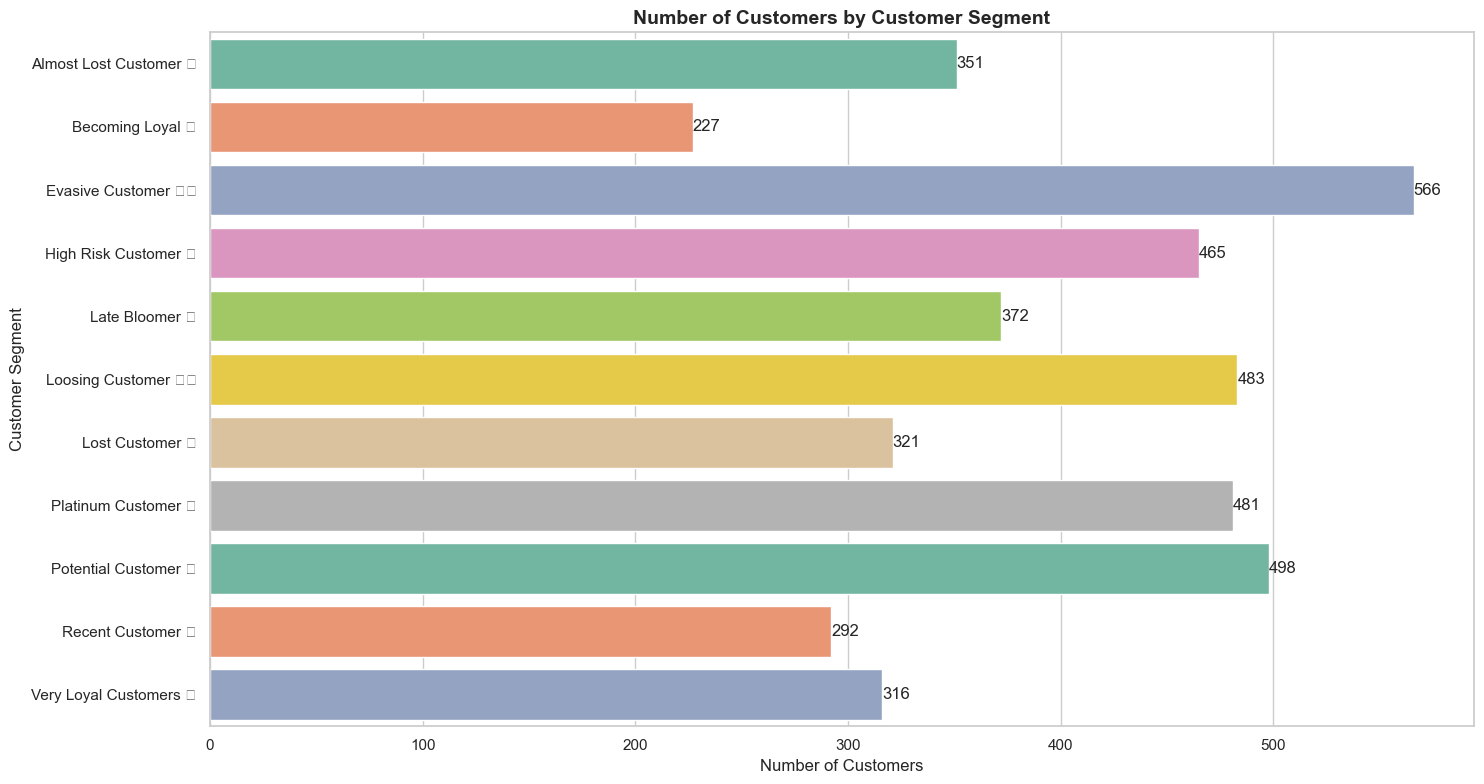

In [1898]:


plt.figure(figsize=(15,8))

sns.barplot(
    y='Segment',
    x='Number of Customers',
    palette='Set2',
    data=cust_per_segment
)

# values show karne ke liye
for index, value in enumerate(cust_per_segment['Number of Customers']):
    plt.text(value, index, str(value), va='center')

plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Customer Segment', fontsize=12)
plt.title('Number of Customers by Customer Segment', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [1899]:
# #Revenue Contribution by Customer Segment

In [1900]:
revenue_segment = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
print(revenue_segment)

Segment
Platinum Customer 💎       4266316.870
Recent Customer 🆕         1152032.180
Loosing Customer ⚠️        773873.571
Potential Customer 🌱       586979.651
Very Loyal Customers 💙     437671.430
Almost Lost Customer 😢     267869.081
High Risk Customer 🚨       263118.831
Evasive Customer 🕵️        237751.670
Late Bloomer 🌼             126626.010
Becoming Loyal 💫           125671.100
Lost Customer ❌             40609.030
Name: Monetary, dtype: float64


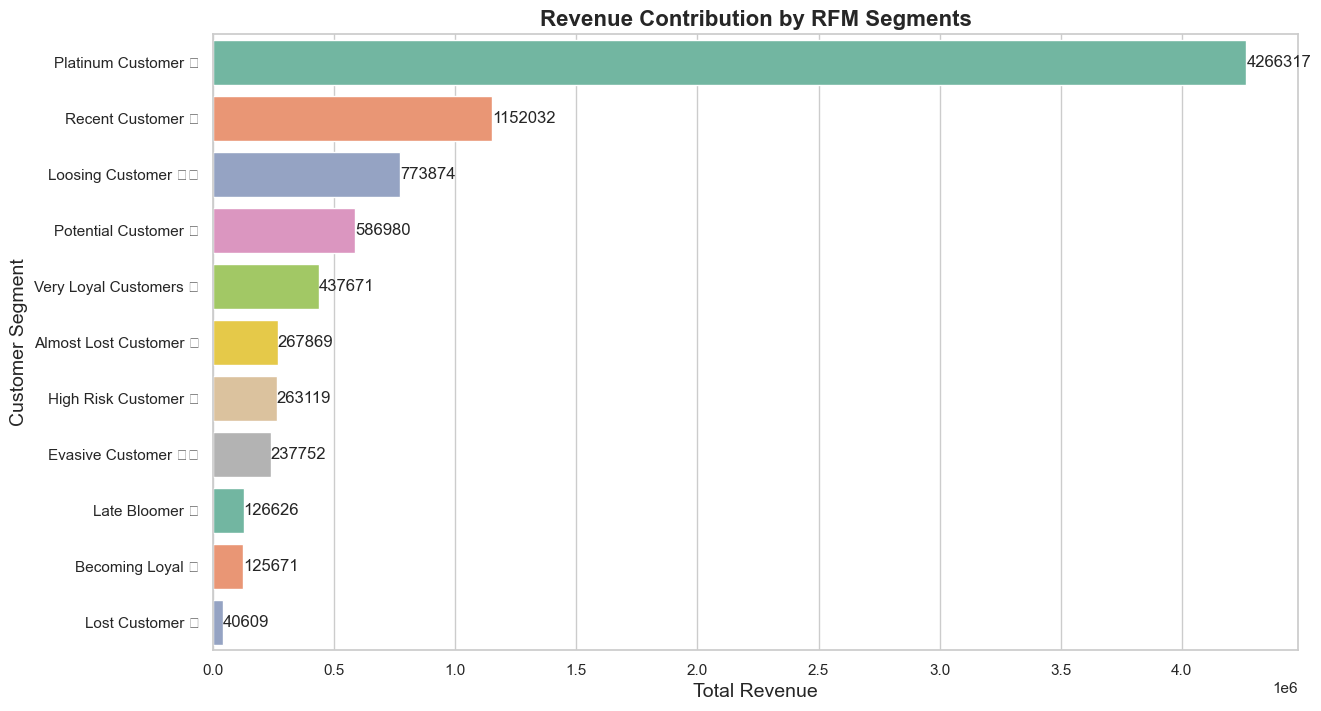

In [1901]:

revenue_segment = rfm.groupby('Segment')['Monetary'].sum().reset_index()
revenue_segment = revenue_segment.sort_values(by='Monetary', ascending=False)


plt.figure(figsize=(14,8))

sns.barplot(
    y='Segment',
    x='Monetary',
    data=revenue_segment,
    palette='Set2'
)

# values show karne ke liye
for index, value in enumerate(revenue_segment['Monetary']):
    plt.text(value, index, f"{value:.0f}", va='center')

plt.title('Revenue Contribution by RFM Segments', fontsize=16, weight='bold')
plt.xlabel('Total Revenue', fontsize=14)
plt.ylabel('Customer Segment', fontsize=14)

plt.show()


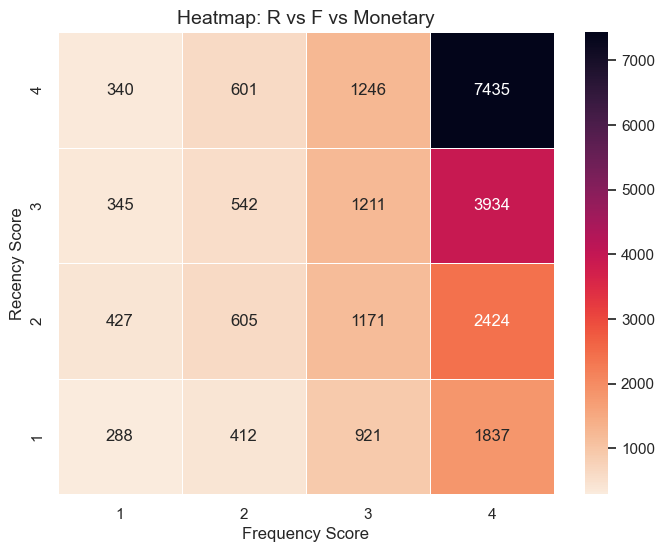

In [1902]:
pivot = rfm.pivot_table(
    values='Monetary',      # what we want to show
    index='R_score',        # Recency score on rows
    columns='F_score',      # Frequency score on columns
    aggfunc='mean'          # average monetary
)
sns.set_theme(style="white")

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap='rocket_r',        # better color, r for reverse color
    linewidths=0.5,        # grid lines
    linecolor='white',
    cbar=True              # color scale bar
)

plt.title("Heatmap: R vs F vs Monetary", fontsize=14)
plt.xlabel("Frequency Score")
plt.ylabel("Recency Score")

plt.show()

## Scatter plot: Recency vs Monetary

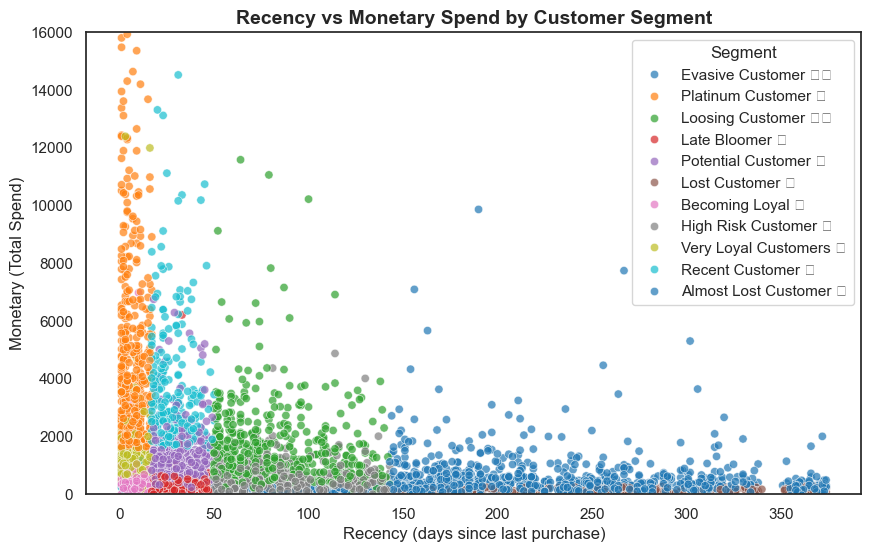

In [1903]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',         # color by customer segment
    palette='tab10',       # colorful and readable
    alpha=0.7
)

plt.title("Recency vs Monetary Spend by Customer Segment", fontsize=14, fontweight='bold')
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Monetary (Total Spend)")
plt.ylim(0, 16000)  # Limit Monetary axis to 16,000    

plt.show()


# #Frequency vs Monetary

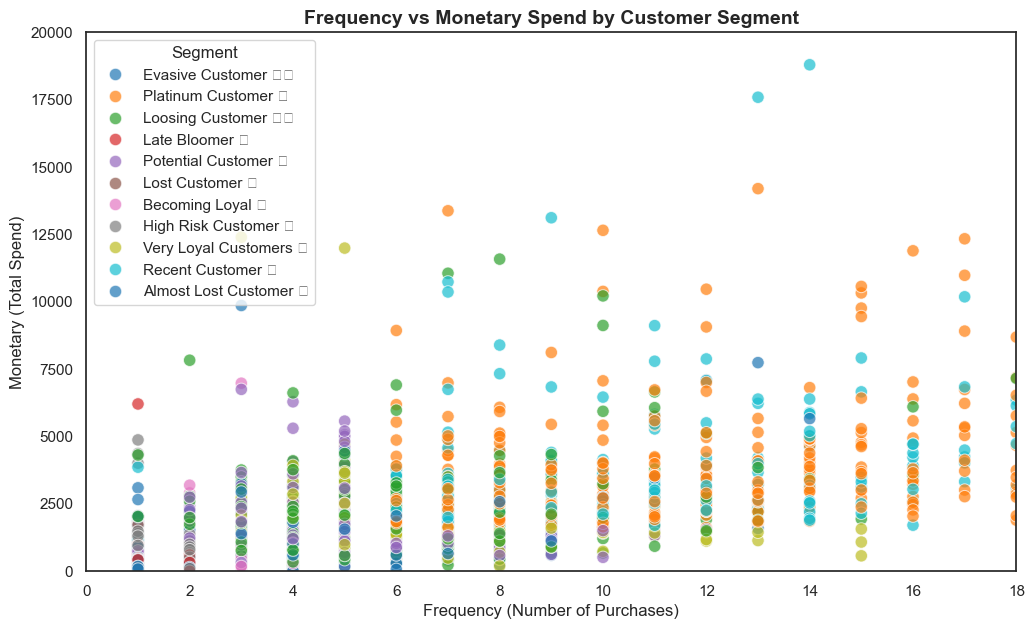

In [1904]:


plt.figure(figsize=(12,7))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',        # color by customer segment
    palette='tab10',      # colorful and readable
    alpha=0.7,
    s=80                  # point size
)

plt.title("Frequency vs Monetary Spend by Customer Segment", fontsize=14, fontweight='bold')
plt.xlabel("Frequency (Number of Purchases)")
plt.ylabel("Monetary (Total Spend)")
plt.ylim(0, 20000)        # Limit Monetary axis
plt.xlim(0, 18)        # Limit Monetary axis

plt.show()

In [1905]:

# Segment-wise revenue nikaalo
revenue_segment= rfm.groupby('Segment')['Monetary'].sum().reset_index()
revenue_segment.rename(columns={'Monetary':'revenue_segment'}, inplace=True)

# RFM final dataframe me merge karo
rfm_final = rfm[['CustomerID','Recency','Frequency','Monetary','Segment']]

# Merge segment revenue
rfm_final = rfm_final.merge(revenue_segment, on='Segment', how='left')

# CSV me save karo
rfm_final.to_csv("rfm_final_with_revenue.csv", index=False)

# # Kmeans cluster 

In [1906]:
x = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(x_scaled)


In [1907]:
#cluster analysis
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_summary)

            Recency  Frequency       Monetary
Cluster                                      
0         14.849315  19.652055    7080.121151
1        250.284102   1.799624     452.903444
2          6.181818  88.363636   54563.856364
3         44.813635   3.756766    1126.818884
4          3.666667  64.666667  241083.226667


In [1908]:


# Optional: map clusters to human-readable segments
segment_map = { 0:  'Loyal 💙',  # active + good spending
    1: 'Lost ❌',

    2: 'Champions 🏆',

    3: 'Average 🌱',

    4: 'Platinum 💎'
    }
rfm['Segment'] = rfm['Cluster'].map(segment_map)

rfm[['CustomerID','Recency','Frequency','Monetary','Cluster','Segment']].head(20)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,2,0.00,1,Lost ❌
1,12347.0,2,7,4310.00,3,Average 🌱
2,12348.0,75,4,1797.24,3,Average 🌱
3,12349.0,19,1,1757.55,3,Average 🌱
4,12350.0,310,1,334.40,1,Lost ❌
5,12352.0,36,11,1545.41,3,Average 🌱
6,12353.0,204,1,89.00,1,Lost ❌
7,12354.0,232,1,1079.40,1,Lost ❌
8,12355.0,214,1,459.40,1,Lost ❌
9,12356.0,23,3,2811.43,3,Average 🌱


In [1909]:
revenue_segment = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
print(revenue_segment)

Segment
Average 🌱      3289184.323
Loyal 💙        2584244.220
Champions 🏆    1200404.840
Platinum 💎      723249.680
Lost ❌          481436.361
Name: Monetary, dtype: float64


In [1910]:
rfm['Segment'].value_counts()

Segment
Average 🌱      2919
Lost ❌         1063
Loyal 💙         365
Champions 🏆      22
Platinum 💎        3
Name: count, dtype: int64

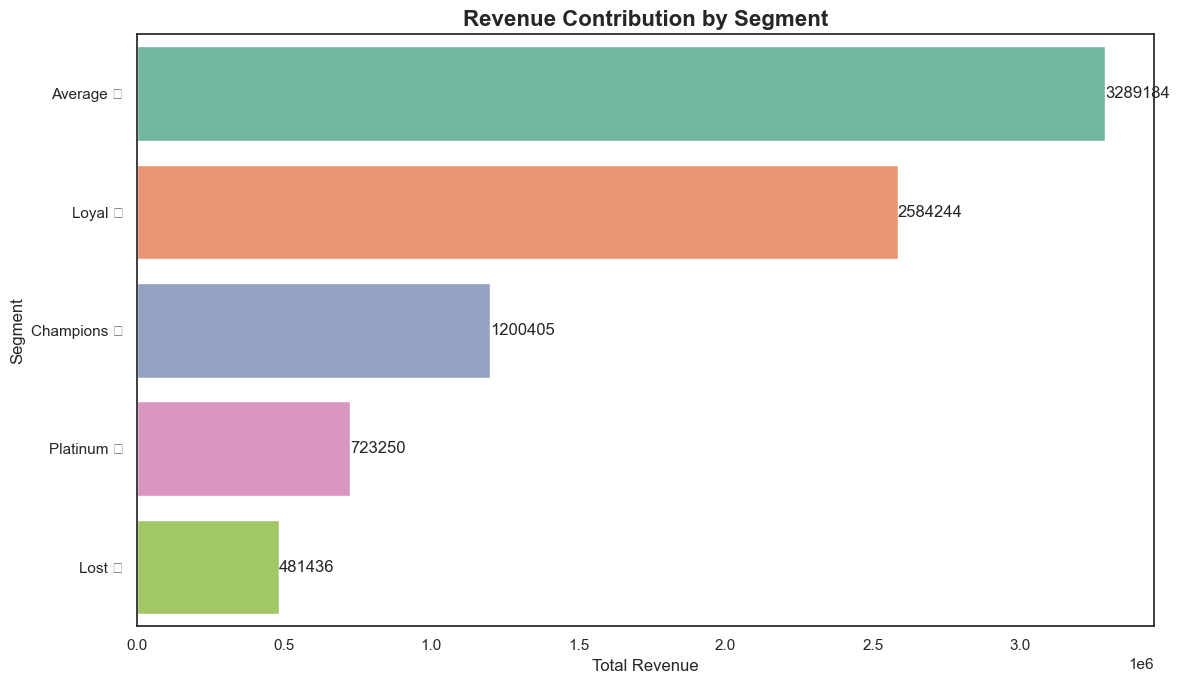

In [1911]:
# convert to dataframe
revenue_df = revenue_segment.reset_index()
revenue_df.columns = ['Segment', 'Revenue']

plt.figure(figsize=(12,7))

sns.barplot(
    y='Segment',
    x='Revenue',
    data=revenue_df,
    palette='Set2'
)

# values show
for i, val in enumerate(revenue_df['Revenue']):
    plt.text(val, i, f"{val:.0f}", va='center')

plt.title('Revenue Contribution by Segment', fontsize=16, weight='bold')
plt.xlabel('Total Revenue')
plt.ylabel('Segment')

plt.tight_layout()
plt.show()


In [1912]:

rfm_final = rfm[[
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary',
    'R_score',
    'F_score',
    'M_score',
    'RFM_Score',
    'Segment',
    'Cluster'
]]

final_df = df.merge(
    rfm_final,
    on='CustomerID',
    how='left'
)

final_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,302,35,5303.48,1,4,4,144,Loyal 💙,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,302,35,5303.48,1,4,4,144,Loyal 💙,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,302,35,5303.48,1,4,4,144,Loyal 💙,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,302,35,5303.48,1,4,4,144,Loyal 💙,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,302,35,5303.48,1,4,4,144,Loyal 💙,0


# #Customer-level segmentation was merged with transaction-level data, resulting in repeated segment labels across transactions of the same customer, which is expected.”

In [1913]:
# full_data = df.merge(
#     rfm[['CustomerID','Segment','Cluster']],
#     on='CustomerID',
#     how='left'
# )
# full_data = full_data.drop_duplicates()

# full_data.head(10)


# # Top 5 products per segment 

In [1914]:
top_products = full_data.groupby(['Segment','Description'])['Quantity'].sum().reset_index()
top_products.sort_values(['Segment','Quantity'], ascending=[True,False], inplace=True)

# Top 5 products per segment
top5 = top_products.groupby('Segment').head(5)

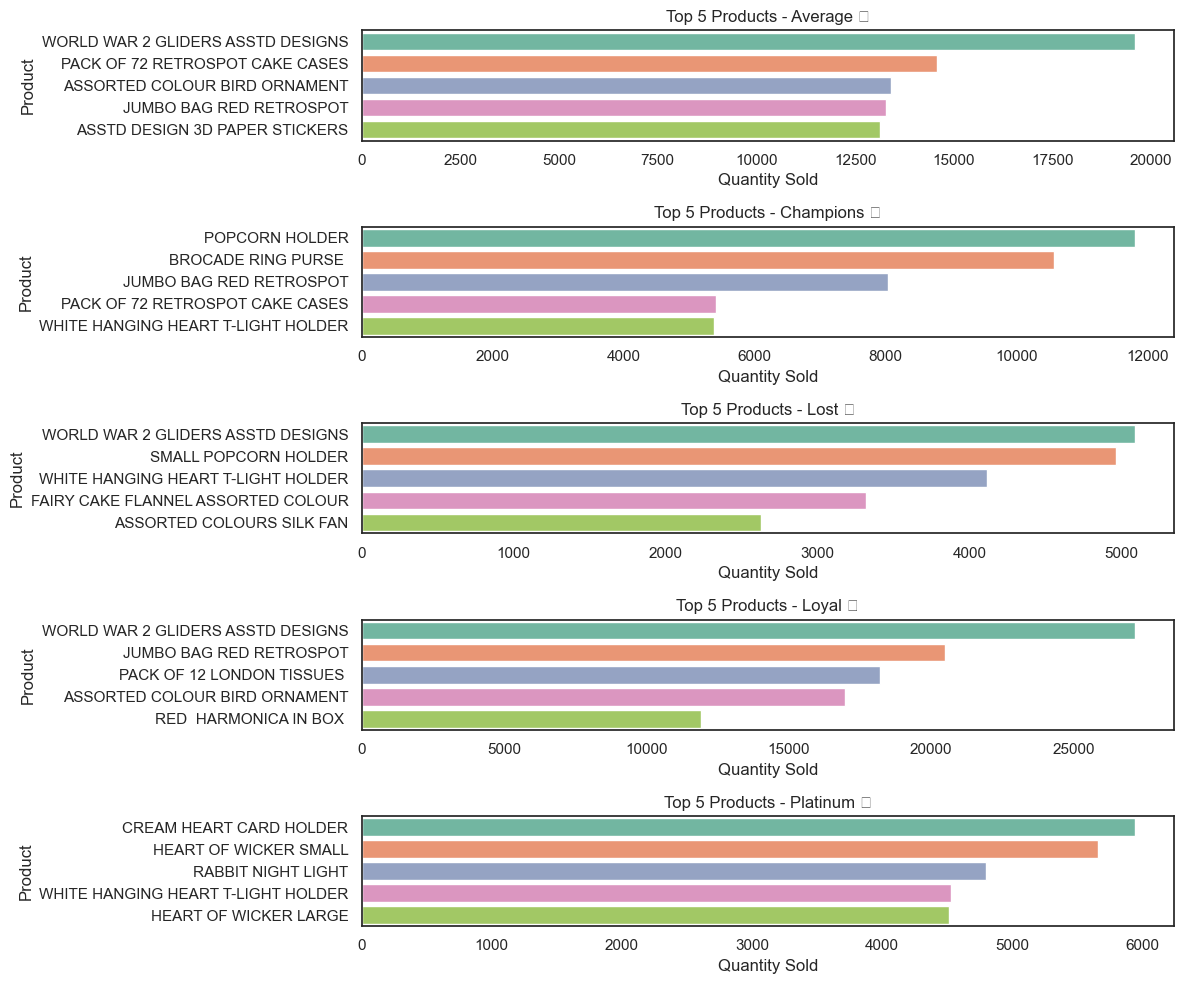

In [1915]:
segments = top5['Segment'].unique()
plt.figure(figsize=(12,10))

for i, seg in enumerate(segments,1):
    plt.subplot(len(segments),1,i)
    temp = top5[top5['Segment']==seg]
    sns.barplot(x='Quantity', y='Description', data=temp, palette='Set2')
    plt.title(f"Top 5 Products - {seg}")
    plt.xlabel("Quantity Sold")
    plt.ylabel("Product")

plt.tight_layout()
plt.show()

# # Hybrid recommendation

In [1916]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# # unique products
# products = df_cleaned[['Description']].drop_duplicates().reset_index(drop=True)

# tfidf = TfidfVectorizer(stop_words='english')

# tfidf_matrix = tfidf.fit_transform(products['Description'])

# tfidf_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# tfidf_sim_df = pd.DataFrame(
#     tfidf_sim,
#     index=products['Description'],
#     columns=products['Description']
# )

In [1917]:
def hybrid_recommend(customer_id, n=5):
    
    if customer_id not in basket.index:
        return []
    
    bought = basket.loc[customer_id]
    bought = bought[bought > 0].index.tolist()
    
    scores = {}
    
    # 🔹 1. Product-based (TF-IDF)
    for product in bought:
        if product in tfidf_sim_df.index:
            similar_products = tfidf_sim_df[product].sort_values(ascending=False)[1:6]
            
            for sim_product, score in similar_products.items():
                if sim_product not in bought:
                    scores[sim_product] = scores.get(sim_product, 0) + score
    
    # 🔹 2. Collaborative (customer similarity)
    if customer_id in customer_sim_df.index:
        similar_customers = customer_sim_df.loc[customer_id] \
                                           .sort_values(ascending=False)[1:6]
        
        similar_ids = similar_customers.index
        
        for sim_id in similar_ids:
            sim_products = basket.loc[sim_id]
            sim_products = sim_products[sim_products > 0]
            
            for product in sim_products.index:
                if product not in bought:
                    scores[product] = scores.get(product, 0) + 1
    
    # 🔹 3. Sort
    recommended = sorted(scores, key=scores.get, reverse=True)
    
    return recommended[:n]

In [1918]:
print(hybrid_recommend(12348))

['PACK OF 12 PINK POLKADOT TISSUES', 'PACK OF 12 SPACEBOY TISSUES', 'PACK OF 60 SPACEBOY CAKE CASES', 'SET OF 60 VINTAGE LEAF CAKE CASES ', 'LUNCH BAG  BLACK SKULL.']


In [1919]:
stop_words = ['of','set','pack','and','the','in','to','for','on','with','a','an']

def clean_text(text):
    return [w for w in text.lower().split() if w not in stop_words]

def match_score(purchased, recommended):
    p_words = set(clean_text(purchased))
    r_words = set(clean_text(recommended))
    
    return len(p_words & r_words)

In [1920]:
all_data = []

for customer_id in basket.index[:50]:   # sample 100
    
    purchased = basket.loc[customer_id]
    purchased = purchased[purchased > 0].index.tolist()
    
    recommended = hybrid_recommend(customer_id)

    purchased_str = ", ".join(purchased[:5])
    recommended_str = ", ".join(recommended)
    
    all_data.append({
        "CustomerID": customer_id,
        # "Purchased": ", ".join(purchased[:5]),
        # "Recommended": ", ".join(recommended),
        "Purchased": purchased_str,
        "Recommended": recommended_str,
         "Match_Score": match_score(purchased_str, recommended_str)
    })

hybrid_df = pd.DataFrame(all_data)

hybrid_df.head(30)

,CustomerID,Purchased,Recommended,Match_Score
0,12346,,"PAPER CHAIN KIT VINTAGE CHRISTMAS, WORLD WAR 2...",0
1,12347,"3D DOG PICTURE PLAYING CARDS, 3D SHEET OF CAT ...","60 CAKE CASES VINTAGE CHRISTMAS, ALARM CLOCK B...",4
2,12348,"60 CAKE CASES DOLLY GIRL DESIGN, 60 CAKE CASES...","PACK OF 12 PINK POLKADOT TISSUES, PACK OF 12 S...",5
3,12349,"16 PIECE CUTLERY SET PANTRY DESIGN, 20 DOLLY P...","STRAWBERRY CERAMIC TRINKET BOX, PLASTERS IN TI...",2
4,12350,"4 TRADITIONAL SPINNING TOPS, BATHROOM METAL SI...","RED SPOTTY BISCUIT TIN, SET/2 RED RETROSPOT TE...",1
5,12352,"ANTIQUE GLASS PEDESTAL BOWL, BAKING SET 9 PIEC...","CERAMIC STRAWBERRY DESIGN MUG, STRAWBERRY CERA...",0
6,12353,"CERAMIC CAKE BOWL + HANGING CAKES, CERAMIC CAK...","MINI CAKE STAND HANGING STRAWBERY, SWEETHEART...",5
7,12354,"3 TIER CAKE TIN GREEN AND CREAM, ASSORTED COLO...","GREEN POLKADOT PLATE , GREEN POLKADOT BOWL, RE...",6
8,12355,"DOUGHNUT LIP GLOSS , GREEN REGENCY TEACUP AND ...","SET/3 OCEAN SCENT CANDLE JEWEL BOX, ROSE SCENT...",0
9,12356,"60 CAKE CASES DOLLY GIRL DESIGN, 60 TEATIME FA...","CERAMIC CAKE STAND + HANGING CAKES, MINI CAKE ...",2


<Axes: >

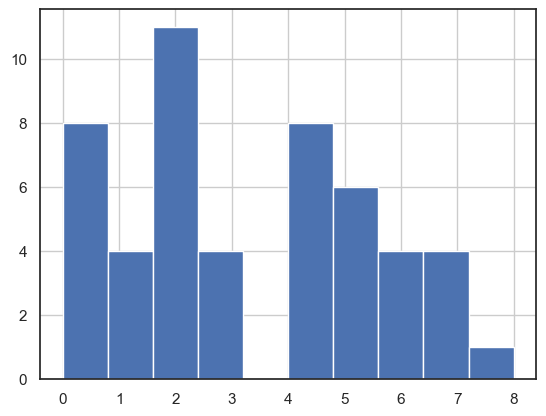

In [1921]:
hybrid_df["Match_Score"].hist()

In [1922]:
final_df.to_csv('final_customer_data.csv', index=False)

rfm_final.to_csv("rfm_final_upload.csv", index=False)

In [1923]:
import os
print(os.getcwd())   # ye dekho kaha se notebook run ho rahi hai
print(os.listdir())  # ye dekho kaun kaun si files available hain

C:\Users\admin\pro4
['.ipynb_checkpoints', 'Customer Segmentation.ipynb', 'customer_segmentation_data.csv', 'data.csv', 'df.pkl', 'final_customer_data.csv', 'full_data.pkl', 'hybrid_df.pkl', 'kmeans_model.pkl', 'rfm.pkl', 'rfm_final_upload.csv', 'rfm_final_with_revenue.csv', 'scaler.pkl', 'segment_map.pkl', 'Untitled.ipynb']


In [1924]:
import pickle
pickle.dump(rfm, open('rfm.pkl','wb'))  # save current rfm dataframe
pickle.dump(hybrid_df, open('hybrid_df.pkl','wb'))  # save current rfm dataframe
pickle.dump(full_data, open('full_data.pkl','wb'))  # save current rfm dataframe
pickle.dump(segment_map, open('segment_map.pkl','wb'))  # save current rfm dataframe
df.to_pickle('df.pkl')
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# Save kmeans model
pickle.dump(kmeans, open('kmeans_model.pkl', 'wb'))